In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('TV_Final.csv')

In [3]:
df.head()

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
0,TOSHIBA,Ultra HD LED,55,37999,54990,VIDAA,4.3
1,TCL,QLED Ultra HD,55,52999,129990,Android,4.4
2,realme,HD LED,32,13999,17999,Android,4.3
3,Mi,HD LED,32,14999,19999,Android,4.4
4,realme,HD LED,32,12999,21999,Android,4.3


In [5]:
df.shape

(912, 7)

In [6]:
df.columns

Index(['Brand', 'Resolution', 'Size ', 'Selling Price', 'Original Price',
       'Operating System', 'Rating'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             912 non-null    object 
 1   Resolution        912 non-null    object 
 2   Size              912 non-null    int64  
 3   Selling Price     912 non-null    int64  
 4   Original Price    912 non-null    int64  
 5   Operating System  901 non-null    object 
 6   Rating            692 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 50.0+ KB


In [8]:
df.isna().sum()

Brand                 0
Resolution            0
Size                  0
Selling Price         0
Original Price        0
Operating System     11
Rating              220
dtype: int64

In [9]:
df['Brand']=df['Brand'].replace(['Samsung'],'SAMSUNG')

In [13]:
df.nunique()

Brand                58
Resolution            5
Size                 27
Selling Price       515
Original Price      455
Operating System      7
Rating               25
dtype: int64

In [11]:
df['Resolution'].unique()

array(['Ultra HD LED', 'QLED Ultra HD', 'HD LED', 'Full HD LED',
       'HD Plasma'], dtype=object)

In [14]:
df['Brand'].unique()

array(['TOSHIBA', 'TCL ', 'realme ', 'Mi ', 'OnePlus', 'Hisense', 'LG ',
       'MarQ by Flipkart', 'iFFALCON by TCL', 'Coocaa ', 'SAMSUNG',
       'Infinix', 'Vu', 'Nokia ', 'Thomson', 'SONY ', 'KODAK ',
       'MOTOROLA', 'PHILIPS', 'Acer', 'Blaupunkt', 'Adsun', 'T-Series',
       'Panasonic', 'Micromax', 'Sansui ', 'Croma ', 'Candes ', 'Dyanora',
       'Haier ', 'Onida', 'RGL ', 'Lloyd ', 'LumX ', 'Onix ', 'IMPEX ',
       'BPL ', 'CloudWalker', 'Oxygen ', 'Power Guard', 'Akai ', 'VG ',
       'Sun King', 'Compaq ', 'HUIDI ', 'Intex ', 'DETEL ', 'JVC',
       'G-TEN ', 'Skyworth', 'Maser ', 'Sanyo ', 'MURPHY ', 'Dektron',
       'Sharp ', 'KRISONS', 'Weston ', 'AISEN  '], dtype=object)

In [16]:
df['Brand'].groupby(df['Resolution']).count().sort_values(ascending=False)

Resolution
Ultra HD LED     399
HD LED           229
Full HD LED      220
QLED Ultra HD     60
HD Plasma          4
Name: Brand, dtype: int64

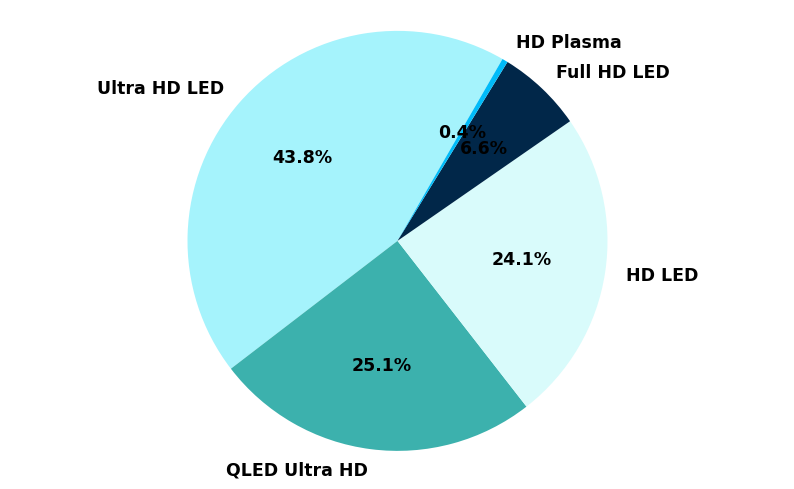

In [41]:
labels = 'Ultra HD LED', 'QLED Ultra HD', 'HD LED', 'Full HD LED','HD Plasma'
sizes = [399,229,220,60,4]
fig, ax = plt.subplots(figsize=(10,6))
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, colors=["#a5f3fc","#3CB1AD","#d9fbfb","#012749","#00bbf9"],autopct='%1.1f%%', startangle=60,textprops={'color':'black','weight':'bold','fontsize':12.5})
ax.axis('equal')
plt.show()

In [44]:
#Which are the top 5 brands for TV?
df['Brand'].groupby(df['Brand']).count().sort_values(ascending=False).iloc[:5]

Brand
SAMSUNG      146
LG           122
SONY          62
TCL           44
Panasonic     30
Name: Brand, dtype: int64

Brand 'Samsung' clearly offers the maximum number of Televisions in the market closely followed by LG.
While brands like Sony, TCL and Panasonic offer quite lesser number of products when compared to these two brands.

<Axes: xlabel='count', ylabel='Brand'>

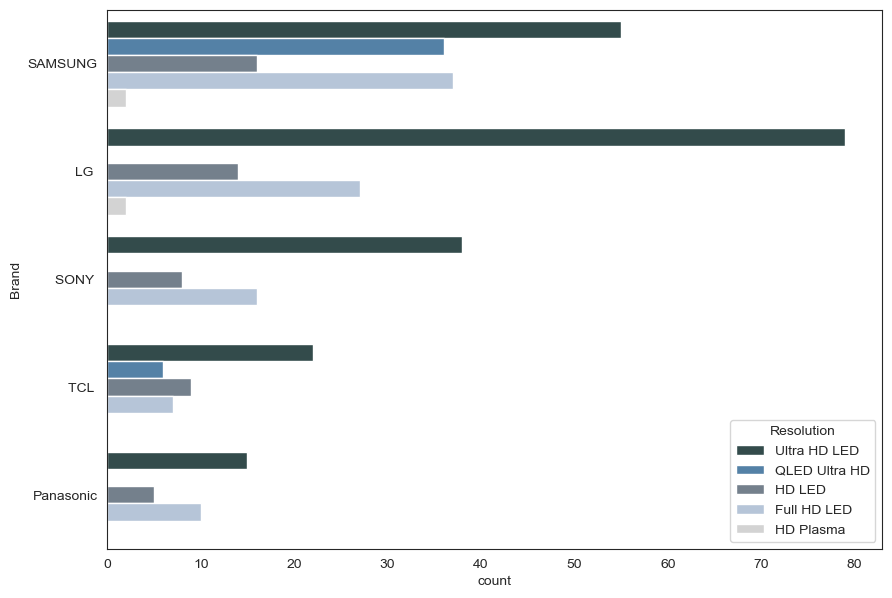

In [71]:
#Brands and Resolution
sns.set_style('white')
plt.figure(figsize=(10,7))
colors = ['#2F4F4F',  # dark slate gray
          '#4682B4',  # steel blue
          '#708090',  # slate gray
          '#B0C4DE',  # light steel blue
          '#D3D3D3']  # light gray

sns.countplot(
    y="Brand",
    hue="Resolution",
    data=df,
    palette=colors,
    order=df["Brand"].value_counts().iloc[:5].index
)


              While Samsung offers products in all Resolution categories, LG does not offer a type 'QLED Ultra HD'.

In [49]:
#Are TVs with higher ratings more expensive or do expensive TVs from well-known brands have higher ratings indicating premium quality?
round(df.groupby('Brand')['Rating'].mean().sort_values(ascending=False),1)

Brand
SONY                4.5
OnePlus             4.4
Hisense             4.4
Haier               4.4
Vu                  4.4
TOSHIBA             4.4
MOTOROLA            4.3
Mi                  4.3
Compaq              4.3
Onida               4.3
Thomson             4.3
Onix                4.3
Dektron             4.3
KODAK               4.3
iFFALCON by TCL     4.3
LG                  4.3
realme              4.3
MarQ by Flipkart    4.3
Nokia               4.3
SAMSUNG             4.3
Coocaa              4.2
Blaupunkt           4.2
Weston              4.2
TCL                 4.2
Sanyo               4.2
Infinix             4.2
Intex               4.2
Panasonic           4.2
IMPEX               4.1
Croma               4.1
Sansui              4.1
Micromax            4.1
PHILIPS             4.1
HUIDI               4.1
CloudWalker         4.1
Candes              4.1
Lloyd               4.1
JVC                 4.0
DETEL               4.0
LumX                4.0
Acer                3.9
RGL       

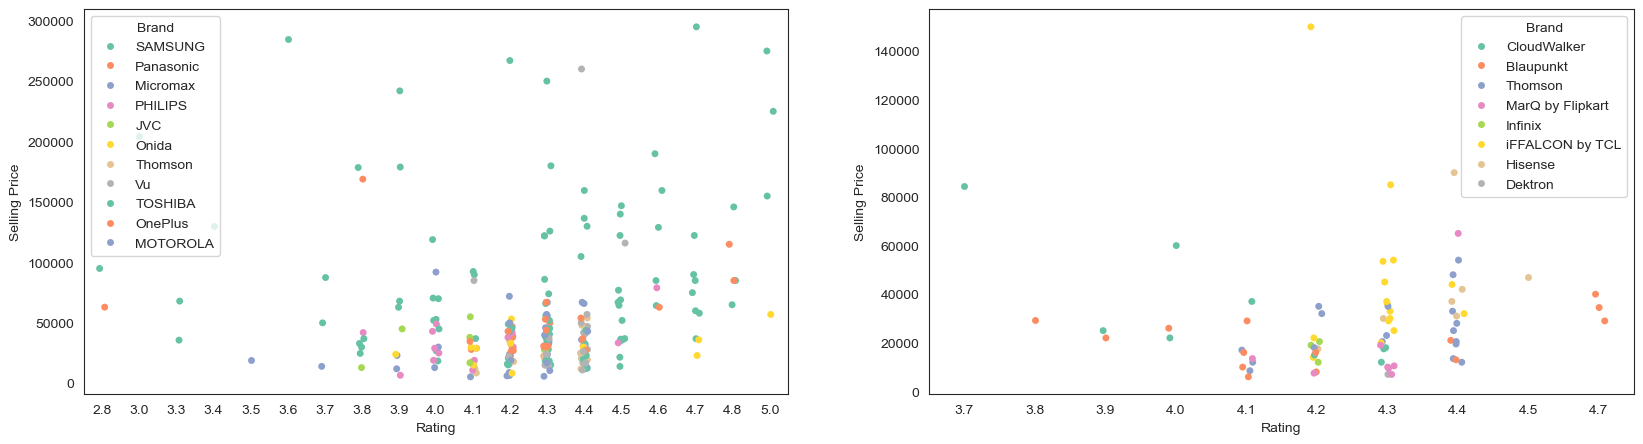

In [77]:
# Rating vs Selling Price
#filter by Known Brands
list1 = ["SONY","OnePlus","Haier","Vu","TOSHIBA","MOTOROLA","Mi","Compaq","Onida","Thomson",
        "KODAK","LG","realme","SAMSUNG","Nokia","Panasonic","Sansui","Micromax","PHILIPS","Samsung","JVC"]

list2 = ["Hisense","Thomson","Onix","KODAK","Dektron","iFFALCON by TCL","MarQ by Flipkart","Nokia","Coocaa","Blaupunkt","Weston","TCL",
        "Infinix","Sanyo","Intex","IMPEX","Croma","HUIDI","CloudWalker","Lloyd", 
        "Candes","Detel","LumX"]

import seaborn as sns
import matplotlib.pyplot as plt

# Generate palettes dynamically based on unique brand counts
colors_f1 = sns.color_palette("Set2", n_colors=df_f1["Brand"].nunique())
colors_f2 = sns.color_palette("Set2", n_colors=df_f2["Brand"].nunique())

fig, axs = plt.subplots(ncols=2, figsize=(20, 5))

ax1 = sns.stripplot(
    x="Rating", y="Selling Price",
    data=df_f1, hue="Brand",
    palette=colors_f1, ax=axs[0]
)

ax2 = sns.stripplot(
    x="Rating", y="Selling Price",
    data=df_f2, hue="Brand",
    palette=colors_f2, ax=axs[1]
)


The first plot on the left side shows well-known Brands with expensive TVs and their ratings while the second one on the right shows new and lesser-known brands with their selling prices and ratings. From the second plot, even the lesser known brands have a higher rating >4.0. So, it is possible that ratings are not highly influnced by brand name alone.

In [51]:
import altair as alt
alt.Chart(df).mark_point(filled=True,size=40).encode(
    x='Original Price',
    y='Selling Price',
    color='Brand',
    tooltip=['Brand', 'Selling Price', 'Original Price']
).interactive()

alt.Chart(...)

# Average selling price by Resolution

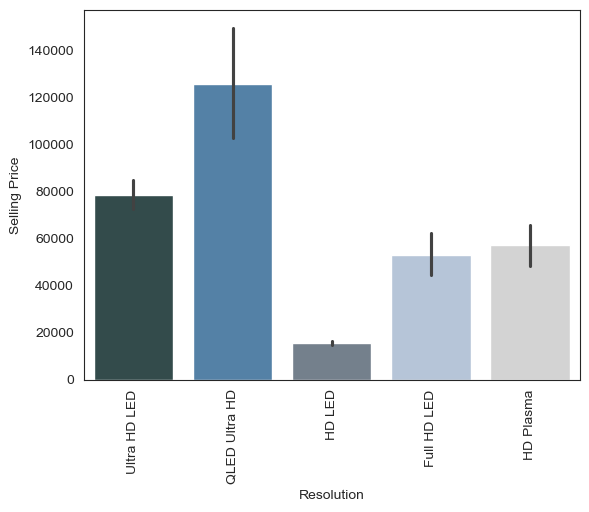

In [72]:

colors = ['#2F4F4F',  # dark slate gray
          '#4682B4',  # steel blue
          '#708090',  # slate gray
          '#B0C4DE',  # light steel blue
          '#D3D3D3']  # light gray


sns.barplot(
    x="Resolution",
    y="Selling Price",
    data=df,
    hue="Resolution",
    palette=colors,
    legend=False
)

plt.xticks(rotation="vertical")

plt.show()

# Average selling price by Brand

In [56]:
df.groupby('Brand')['Selling Price'].mean().sort_values(ascending=False).round(1)

Brand
Sharp               149672.0
SAMSUNG             107034.7
LG                   96914.4
Hisense              89795.4
SONY                 89342.8
TCL                  55798.3
iFFALCON by TCL      54234.4
Panasonic            53494.0
Akai                 52002.8
OnePlus              47375.8
Vu                   46649.9
Compaq               45999.0
Sanyo                45499.0
Weston               43390.0
Oxygen               40326.3
Nokia                38862.6
TOSHIBA              38852.8
MOTOROLA             38399.0
Sansui               37671.9
Haier                36616.2
AISEN                35462.5
BPL                  34617.2
Onix                 34216.2
Lloyd                34161.8
PHILIPS              34113.8
JVC                  32496.3
CloudWalker          32331.3
Acer                 31664.7
Mi                   30787.1
Power Guard          30509.7
Onida                29707.2
IMPEX                28819.4
Intex                27340.7
Micromax             26869.6
Thomson 

In [57]:
#filter dataframe
df_p1=df_f1[(df_f1["Selling Price"] >=10000) & (df_f1["Selling Price"] <= 100000)]
df_p1.iloc[:2]

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
0,TOSHIBA,Ultra HD LED,55,37999,54990,VIDAA,4.3
5,OnePlus,HD LED,32,15999,19999,Android,4.3


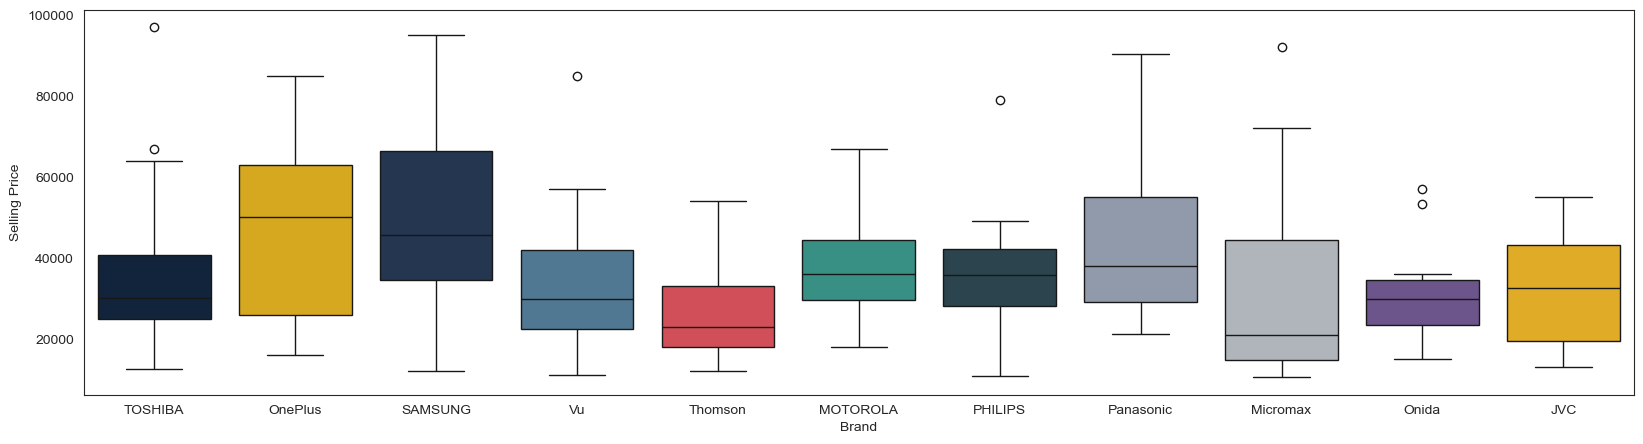

In [74]:
#Box plot to denote average selling prices
fig, ax = plt.subplots(figsize=(20,5))
colors = [
    '#0a2342',  # deep navy
    '#f5b700',  # gold
    '#1d3557',  # slate blue
    '#457b9d',  # steel blue
    '#e63946',  # muted red
    '#2a9d8f',  # teal
    '#264653',  # dark slate
    '#8d99ae',  # gray
    '#adb5bd',  # light gray
    '#6a4c93',  # muted purple
    '#ffba08'   # amber accent
]


ax = sns.boxplot(
    x="Brand",
    y="Selling Price",
    data=df_p1,
    hue="Brand",
    palette=colors,
    legend=False
)



It is clear that from the well-known brands SAMSUNG Televisions are the most expensive while Micromax Televisions are the most affordable ones.

In [59]:
#filter dataframe
df_p2=df_f2[(df_f2["Selling Price"] >=10000) & (df_f2["Selling Price"] <= 100000)]
df_p2.iloc[:2]

,Brand,Resolution,Size,Selling Price,Original Price,Operating System,Rating
11,Hisense,Ultra HD LED,55,36999,49990,Android,4.4
15,Hisense,Ultra HD LED,70,89999,119990,Android,4.4


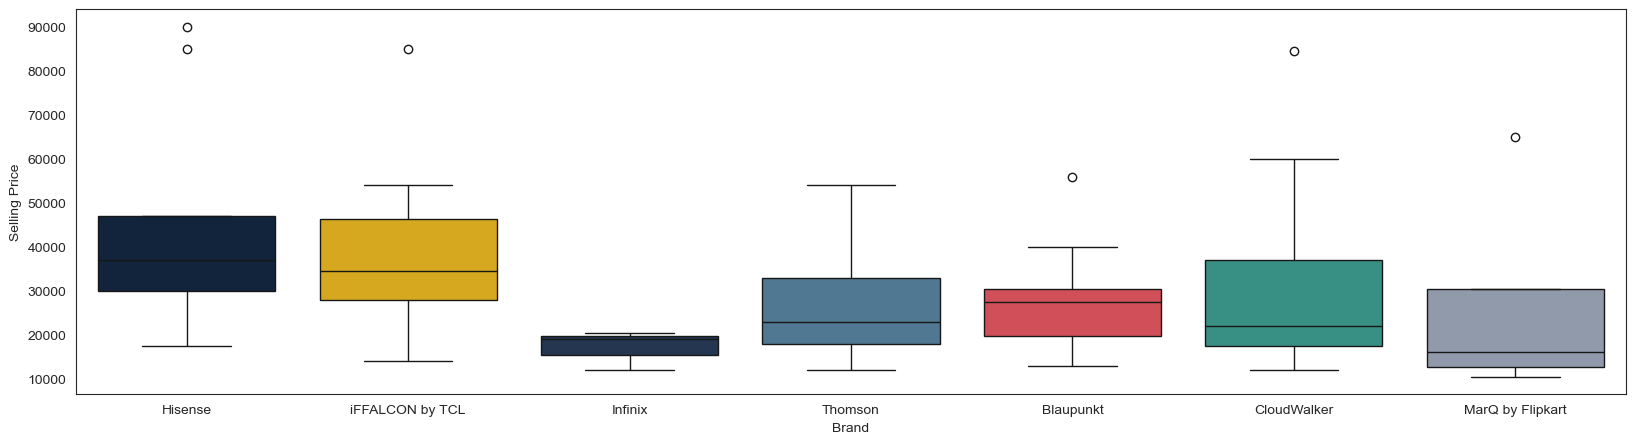

In [75]:
#Box plot to denote average selling prices
fig, ax = plt.subplots(figsize=(20,5))
colors = [
    '#0a2342',  # deep navy
    '#f5b700',  # gold
    '#1d3557',  # slate blue
    '#457b9d',  # steel blue
    '#e63946',  # muted red
    '#2a9d8f',  # teal
    '#8d99ae'   # gray
]

ax = sns.boxplot(
    x="Brand",
    y="Selling Price",
    data=df_p2
    hue="Brand",
    palette=colors,
    legend=False
)


From the new and upcoming brands Hisense Televisions are the most expensive while MarQ by Flipkart Televisions are the most affordable ones.

# Average selling price by Operating System

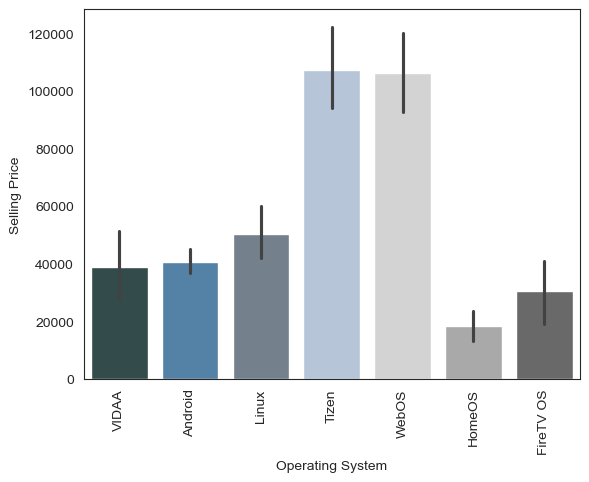

In [76]:
colors = [
    '#2F4F4F',  # dark slate gray
    '#4682B4',  # steel blue
    '#708090',  # slate gray
    '#B0C4DE',  # light steel blue
    '#D3D3D3',  # light gray
    '#A9A9A9',  # dim gray
    '#696969'   # dark gray
]


sns.barplot(
    x='Operating System',
    y='Selling Price',
    data=df,
    hue='Operating System',
    palette=colors,
    legend=False
)

plt.xticks(rotation="vertical")
plt.show()

From the above chart, it is clear the Television sets with Tizen and WebOS are most expensive while HomeOS Television sets are the most affordable ones.